# Phase 1 ver3 — 실험 결과 종합 분석

**분석 대상:** `results/phase1_ver3/{dataset}/{method}/`

**데이터셋:** HumanEval, MBPP  
**방법:** single_shot, retry_only, best_of_n, repair_loop, planner_coder

---
## 목차
1. 데이터 로드
2. 핵심 지표 비교 (pass@1, exec_success_rate, conditional_pass)
3. 방법별 비교 시각화
4. Failure Type 분석
5. Transition Path 분석 (retry / repair)
6. 토큰 / 레이턴시 효율성 분석
7. Step-level 상세 분석
8. MBPP Failure Breakdown

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ────────────────────────────────────────────
# 한글 폰트 설정 (NanumGothic 또는 NotoSansCJK)
# ────────────────────────────────────────────
def set_korean_font():
    # 1순위: 나눔고딕 (apt 패키지로 설치 가능)
    nanum = [f.fname for f in fm.fontManager.ttflist if 'NanumGothic' in f.name]
    # 2순위: Noto Sans CJK (많은 Linux 배포판에 포함)
    noto  = [f.fname for f in fm.fontManager.ttflist if 'NotoSansCJK' in f.name or 'Noto Sans CJK' in f.name]

    if nanum:
        plt.rcParams['font.family'] = 'NanumGothic'
    elif noto:
        plt.rcParams['font.family'] = 'Noto Sans CJK KR'
    else:
        print("⚠ 한글 폰트를 찾을 수 없습니다. 아래 명령어로 설치하세요:")
        print("  sudo apt-get install -y fonts-nanum && fc-cache -fv")
        print("  설치 후 커널을 재시작하세요.")
        return

    plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
    print(f"✔ 한글 폰트 설정 완료: {plt.rcParams['font.family']}")

set_korean_font()

# ── 경로 설정 ──
NOTEBOOK_DIR = Path(os.path.abspath(''))
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent   # analysis/exp_phase1_ver3 → project root
RESULTS_ROOT = PROJECT_ROOT / 'results' / 'phase1_ver3'

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'RESULTS_ROOT : {RESULTS_ROOT}')

# ── 스타일 설정 ──
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

DATASETS   = ['humaneval', 'mbpp']
METHODS    = ['single', 'retry', 'bestofn', 'repair', 'planner_coder']
METHOD_LABELS = {
    'single'        : 'Single-shot',
    'retry'         : 'Retry',
    'bestofn'       : 'Best-of-N',
    'repair'        : 'Repair',
    'planner_coder' : 'Planner-Coder',
}
COLORS = {
    'single'        : '#4C72B0',
    'retry'         : '#DD8452',
    'bestofn'       : '#55A868',
    'repair'        : '#C44E52',
    'planner_coder' : '#8172B2',
}

✔ 한글 폰트 설정 완료: ['NanumGothic']
PROJECT_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration
RESULTS_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration/results/phase1_ver3


---
## 1. 데이터 로드

In [2]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def safe_load_json(path):
    try:
        return load_json(path)
    except Exception:
        return None

def safe_load_jsonl(path):
    try:
        return load_jsonl(path)
    except Exception:
        return []

# ── 전체 결과 수집 ──
summaries      = {}   # (dataset, method) -> summary dict
analyses       = {}   # (dataset, method) -> analysis dict
step_logs_all  = {}   # (dataset, method) -> list of step records
traj_logs_all  = {}   # (dataset, method) -> list of trajectory records

found = []
missing = []

for dataset in DATASETS:
    for method in METHODS:
        method_dir = RESULTS_ROOT / dataset / method
        summary_path = method_dir / 'summary.json'
        if not summary_path.exists():
            missing.append(f'{dataset}/{method}')
            continue

        key = (dataset, method)
        summaries[key]     = safe_load_json(summary_path)
        analyses[key]      = safe_load_json(method_dir / 'analysis.json')
        step_logs_all[key] = safe_load_jsonl(method_dir / 'step_logs.jsonl')
        traj_logs_all[key] = safe_load_jsonl(method_dir / 'trajectory_logs.jsonl')
        found.append(f'{dataset}/{method}')

print(f'✅ 로드 성공 ({len(found)}개):', ', '.join(found))
if missing:
    print(f'⚠️  결과 없음 ({len(missing)}개):', ', '.join(missing))

✅ 로드 성공 (9개): humaneval/single, humaneval/retry, humaneval/bestofn, humaneval/repair, humaneval/planner_coder, mbpp/single, mbpp/retry, mbpp/bestofn, mbpp/repair
⚠️  결과 없음 (1개): mbpp/planner_coder


In [3]:
# ── summary DataFrame 구성 ──
rows = []
for (dataset, method), s in summaries.items():
    if s is None:
        continue
    row = {
        'dataset'              : dataset,
        'method'               : method,
        'method_label'         : METHOD_LABELS.get(method, method),
        'total'                : s.get('total_problems', s.get('total', 0)),
        'num_pass'             : s.get('num_pass', s.get('passed', 0)),
        'pass@1'               : s.get('pass_at_1', s.get('pass@1', 0.0)),
        'exec_success_rate'    : s.get('execution_success_rate', 0.0),
        'conditional_pass'     : s.get('conditional_pass', 0.0),
        'avg_tokens'           : s.get('avg_tokens', 0.0),
        'avg_latency'          : s.get('avg_latency', 0.0),
        'avg_calls'            : s.get('avg_calls', 0.0),
    }
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['dataset', 'method'])

# 방법 순서 고정
method_order = [m for m in METHODS if m in df_summary.index.get_level_values('method').unique()]

print('\n=== Summary DataFrame ===')
display(df_summary[['total', 'num_pass', 'pass@1', 'exec_success_rate', 'conditional_pass',
                     'avg_tokens', 'avg_latency', 'avg_calls']].round(4))


=== Summary DataFrame ===


total  num_pass  pass@1  exec_success_rate  \
dataset   method                                                      
humaneval single           164       121  0.7378             0.8659   
          retry            164       114  0.6951             0.7378   
          bestofn          164       127  0.7744             0.9146   
          repair           164       140  0.8537             0.9329   
          planner_coder    164       130  0.7927             0.9207   
mbpp      single           374       178  0.4759             0.6578   
          retry            374       245  0.6551             0.6684   
          bestofn          374       226  0.6043             0.7781   
          repair           374       253  0.6765             0.6952   

                         conditional_pass  avg_tokens  avg_latency  avg_calls  
dataset   method                                                               
humaneval single                   0.8521    300.3293       2.1841     1.0000  
          retry                    0.9421    709.5915       3.1794     1.6646  
          bestofn                  0.8467    889.0488       6.4004     3.0000  
          repair                   0.9150    794.2134       3.7762     1.5793  
          planner_coder            0.8609    652.1829       1.7963     2.0000  
mbpp      single                   0.7236    236.7406       2.0194     1.0000  
          retry                    0.9800    542.4171       4.0876     1.8770  
          bestofn                  0.7766    701.0294       5.9368     3.0000  
          repair                   0.9731    725.4198       5.2428     1.8529

---
## 2. 핵심 지표 비교표

In [4]:
METRICS = ['pass@1', 'exec_success_rate', 'conditional_pass']
METRIC_LABELS = {
    'pass@1'            : 'pass@1',
    'exec_success_rate' : 'Exec Success Rate',
    'conditional_pass'  : 'Conditional Pass',
}

for dataset in DATASETS:
    if dataset not in df_summary.index.get_level_values('dataset'):
        continue
    sub = df_summary.loc[dataset, METRICS].copy()
    # 방법 순서 정렬
    sub = sub.reindex([m for m in METHODS if m in sub.index])
    sub.index = [METHOD_LABELS.get(m, m) for m in sub.index]
    sub.columns = [METRIC_LABELS[c] for c in sub.columns]

    print(f'\n=== {dataset.upper()} ========================')
    display(sub.style
               .format('{:.4f}')
               .background_gradient(cmap='YlGn', axis=0))


=== HUMANEVAL ========================


,pass@1,Exec Success Rate,Conditional Pass
Single-shot,0.7378,0.8659,0.8521
Retry,0.6951,0.7378,0.9421
Best-of-N,0.7744,0.9146,0.8467
Repair,0.8537,0.9329,0.9150
Planner-Coder,0.7927,0.9207,0.8609



=== MBPP ========================


,pass@1,Exec Success Rate,Conditional Pass
Single-shot,0.4759,0.6578,0.7236
Retry,0.6551,0.6684,0.9800
Best-of-N,0.6043,0.7781,0.7766
Repair,0.6765,0.6952,0.9731


---
## 3. 방법별 비교 시각화

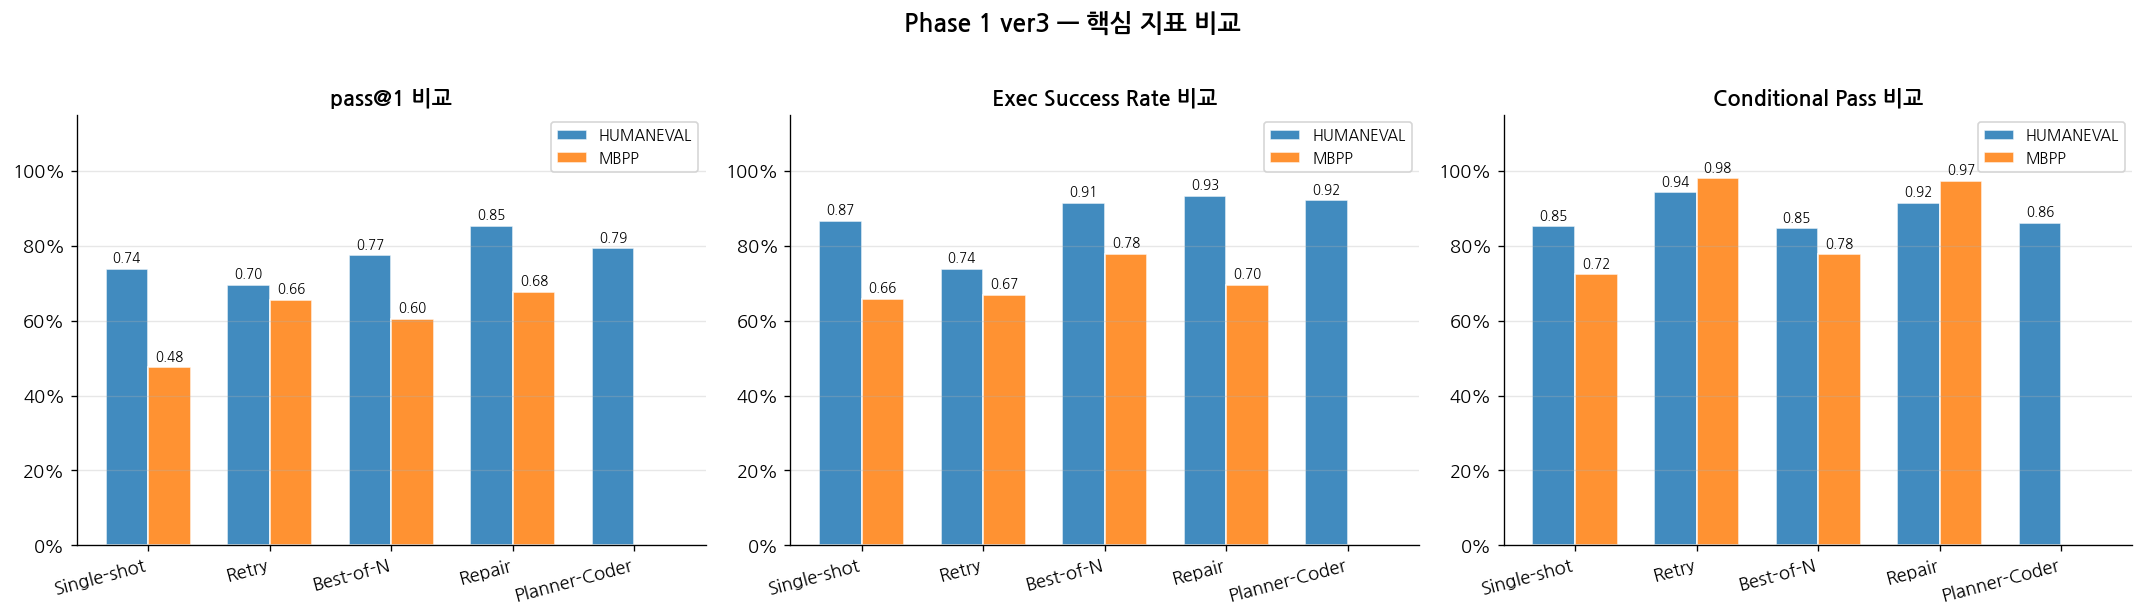

In [5]:
def plot_metric_comparison(df, metric, title, ax, method_order, colors):
    for dataset in DATASETS:
        if dataset not in df.index.get_level_values('dataset'):
            continue
        sub = df.loc[dataset, metric].reindex([m for m in method_order if m in df.loc[dataset].index])
        xs  = range(len(sub))
        bars = ax.bar(
            [x + (DATASETS.index(dataset) * 0.35) for x in xs],
            sub.values,
            width=0.33,
            label=dataset.upper(),
            color=[colors.get(m, '#999') for m in sub.index],
            alpha=0.85 if dataset == 'humaneval' else 0.55,
            edgecolor='white',
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks([x + 0.175 for x in range(len(sub))])
    ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in sub.index], rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(['HumanEval (dark)', 'MBPP (light)'], fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_grouped(df, metric, title, ax):
    data = {}
    for dataset in DATASETS:
        if dataset not in df.index.get_level_values('dataset'):
            continue
        sub = df.loc[dataset, metric]
        for m, v in sub.items():
            data.setdefault(m, {})[dataset] = v

    methods_present = [m for m in METHODS if m in data]
    x = np.arange(len(methods_present))
    w = 0.35
    for di, dataset in enumerate(DATASETS):
        vals = [data[m].get(dataset, 0) for m in methods_present]
        ax.bar(x + di * w, vals, width=w, label=dataset.upper(),
               alpha=0.85, edgecolor='white')
        for xi, v in zip(x + di * w, vals):
            if v > 0:
                ax.text(xi, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in methods_present], rotation=15, ha='right')
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plot_grouped(df_summary, 'pass@1',            'pass@1 비교',            axes[0])
plot_grouped(df_summary, 'exec_success_rate', 'Exec Success Rate 비교', axes[1])
plot_grouped(df_summary, 'conditional_pass',  'Conditional Pass 비교',  axes[2])

plt.suptitle('Phase 1 ver3 — 핵심 지표 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_metric_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Failure Type 분석

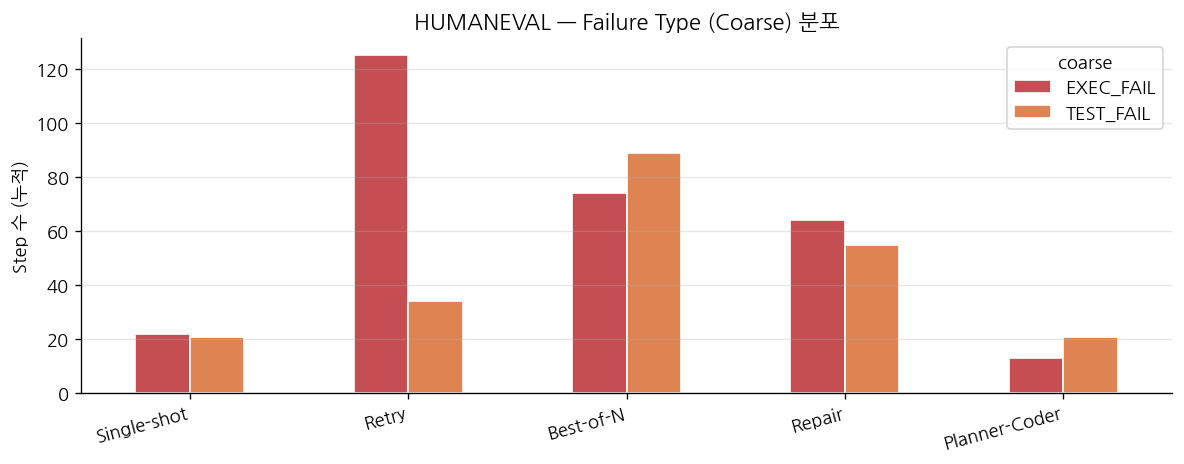


[HUMANEVAL] Coarse Failure Counts:


coarse,EXEC_FAIL,TEST_FAIL
Single-shot,22,21
Retry,125,34
Best-of-N,74,89
Repair,64,55
Planner-Coder,13,21


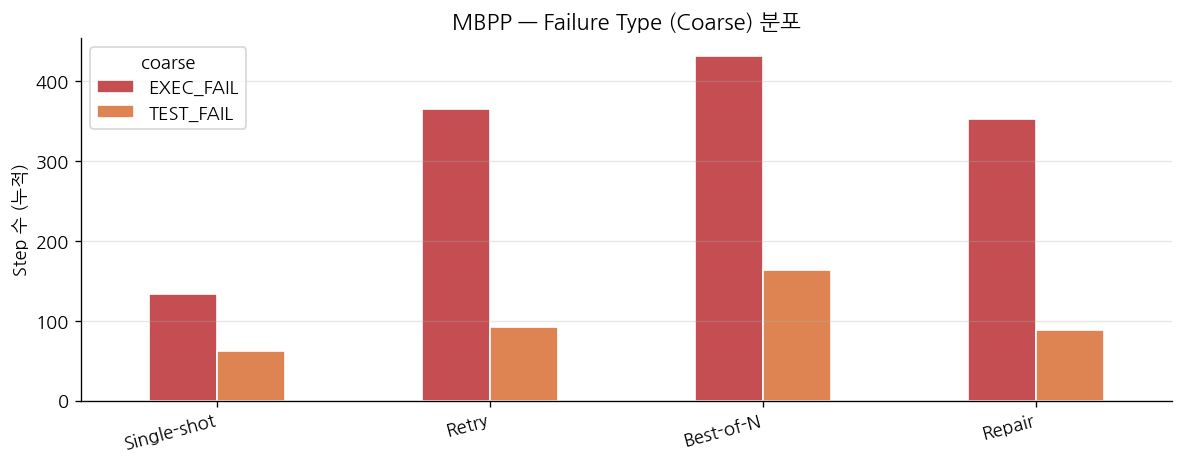


[MBPP] Coarse Failure Counts:


coarse,EXEC_FAIL,TEST_FAIL
Single-shot,134,62
Retry,365,92
Best-of-N,432,164
Repair,352,88


In [6]:
# analysis.json의 failure_type_counts 수집
failure_rows = []
for (dataset, method), an in analyses.items():
    if an is None:
        continue
    ftc = an.get('failure_type_counts', {})
    for status, cnt in ftc.items():
        # coarse prefix (EXEC_FAIL / TEST_FAIL)
        coarse = status.split(':')[0]
        failure_rows.append({
            'dataset': dataset,
            'method' : method,
            'status' : status,
            'coarse' : coarse,
            'count'  : cnt,
        })

df_failure = pd.DataFrame(failure_rows)

if df_failure.empty:
    print('⚠️  failure_type_counts 데이터가 없습니다.')
else:
    for dataset in DATASETS:
        sub = df_failure[df_failure['dataset'] == dataset]
        if sub.empty:
            continue

        pivot = sub.groupby(['method', 'coarse'])['count'].sum().unstack(fill_value=0)
        pivot = pivot.reindex([m for m in METHODS if m in pivot.index])
        pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]

        pivot.plot(kind='bar', figsize=(10, 4), edgecolor='white',
                   title=f'{dataset.upper()} — Failure Type (Coarse) 분포',
                   color=['#C44E52', '#DD8452', '#4C72B0'])
        plt.xticks(rotation=15, ha='right')
        plt.ylabel('Step 수 (누적)')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'fig_failure_coarse_{dataset}.png', bbox_inches='tight', dpi=150)
        plt.show()

        print(f'\n[{dataset.upper()}] Coarse Failure Counts:')
        display(pivot)

In [7]:
# Fine-grained failure type (전체 status 기준)
if not df_failure.empty:
    for dataset in DATASETS:
        sub = df_failure[df_failure['dataset'] == dataset]
        if sub.empty:
            continue

        pivot = sub.groupby(['method', 'status'])['count'].sum().unstack(fill_value=0)
        pivot = pivot.reindex([m for m in METHODS if m in pivot.index])
        pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]

        print(f'\n[{dataset.upper()}] Fine-grained Failure Counts:')
        display(pivot.style.background_gradient(cmap='Reds', axis=None))


[HUMANEVAL] Fine-grained Failure Counts:


status,EXEC_FAIL:IndexError,EXEC_FAIL:KeyError,EXEC_FAIL:NameError,EXEC_FAIL:SyntaxError,EXEC_FAIL:TypeError,EXEC_FAIL:ValueError,TEST_FAIL:AssertionError
Single-shot,1,0,3,16,1,1,21
Retry,0,0,63,58,1,3,34
Best-of-N,5,0,11,52,5,1,89
Repair,3,0,10,47,3,1,55
Planner-Coder,1,1,6,4,0,1,21



[MBPP] Fine-grained Failure Counts:


status,EXEC_FAIL:attribute_error,EXEC_FAIL:code_error,EXEC_FAIL:empty_generation,EXEC_FAIL:indentation_error,EXEC_FAIL:index_error,EXEC_FAIL:key_error,EXEC_FAIL:name_error,EXEC_FAIL:setup_error,EXEC_FAIL:syntax_error,EXEC_FAIL:test_execution_error,EXEC_FAIL:type_error,TEST_FAIL:AssertionError
Single-shot,1,18,0,105,0,0,2,1,4,1,2,62
Retry,1,100,2,115,1,0,2,0,137,5,2,92
Best-of-N,3,49,1,339,5,2,7,0,22,1,3,164
Repair,1,126,1,107,1,1,2,0,108,1,4,88


---
## 5. Transition Path 분석

In [8]:
# analysis.json의 transition_counts 수집
trans_rows = []
for (dataset, method), an in analyses.items():
    if an is None:
        continue
    tc = an.get('transition_counts', {})
    for trans, cnt in tc.items():
        trans_rows.append({
            'dataset'    : dataset,
            'method'     : method,
            'transition' : trans,
            'count'      : cnt,
        })

df_trans = pd.DataFrame(trans_rows)

if df_trans.empty:
    print('⚠️  transition_counts 데이터가 없습니다.')
else:
    # 방법별로 의미 있는 것: retry / repair / bestofn
    iterative_methods = ['retry', 'repair', 'bestofn']
    for dataset in DATASETS:
        sub = df_trans[(df_trans['dataset'] == dataset) &
                       (df_trans['method'].isin(iterative_methods))]
        if sub.empty:
            continue

        pivot = sub.groupby(['method', 'transition'])['count'].sum().unstack(fill_value=0)
        pivot = pivot.reindex([m for m in iterative_methods if m in pivot.index])
        pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]

        print(f'\n[{dataset.upper()}] Transition Counts (retry/repair/bestofn):')
        display(pivot.style.background_gradient(cmap='Blues', axis=None))

        # 핵심 전이: *→PASS (성공 전이)
        success_trans = [c for c in pivot.columns if c.endswith('->PASS')]
        if success_trans:
            print(f'  → PASS 전이 (복구 성공):')
            display(pivot[success_trans])


[HUMANEVAL] Transition Counts (retry/repair/bestofn):


transition,EXEC_FAIL->EXEC_FAIL,EXEC_FAIL->PASS,EXEC_FAIL->SELECT,EXEC_FAIL->TEST_FAIL,PASS->EXEC_FAIL,PASS->PASS,PASS->SELECT,PASS->TEST_FAIL,TEST_FAIL->EXEC_FAIL,TEST_FAIL->PASS,TEST_FAIL->SELECT,TEST_FAIL->TEST_FAIL
Retry,72,5,0,5,0,0,0,0,23,0,0,4
Repair,24,22,0,7,0,0,0,0,16,6,0,20
Best-of-N,31,11,26,6,10,196,108,15,7,12,30,40


  → PASS 전이 (복구 성공):


transition,EXEC_FAIL->PASS,PASS->PASS,TEST_FAIL->PASS
Retry,5,0,0
Repair,22,0,6
Best-of-N,11,196,12



[MBPP] Transition Counts (retry/repair/bestofn):


transition,EXEC_FAIL->EXEC_FAIL,EXEC_FAIL->PASS,EXEC_FAIL->SELECT,EXEC_FAIL->TEST_FAIL,PASS->EXEC_FAIL,PASS->PASS,PASS->SELECT,PASS->TEST_FAIL,TEST_FAIL->EXEC_FAIL,TEST_FAIL->PASS,TEST_FAIL->SELECT,TEST_FAIL->TEST_FAIL
Retry,143,70,0,28,0,0,0,0,79,0,0,8
Repair,135,68,0,35,0,0,0,0,81,0,0,0
Best-of-N,212,51,144,25,55,284,177,10,19,15,53,77


  → PASS 전이 (복구 성공):


transition,EXEC_FAIL->PASS,PASS->PASS,TEST_FAIL->PASS
Retry,70,0,0
Repair,68,0,0
Best-of-N,51,284,15


---
## 6. 토큰 / 레이턴시 효율성 분석

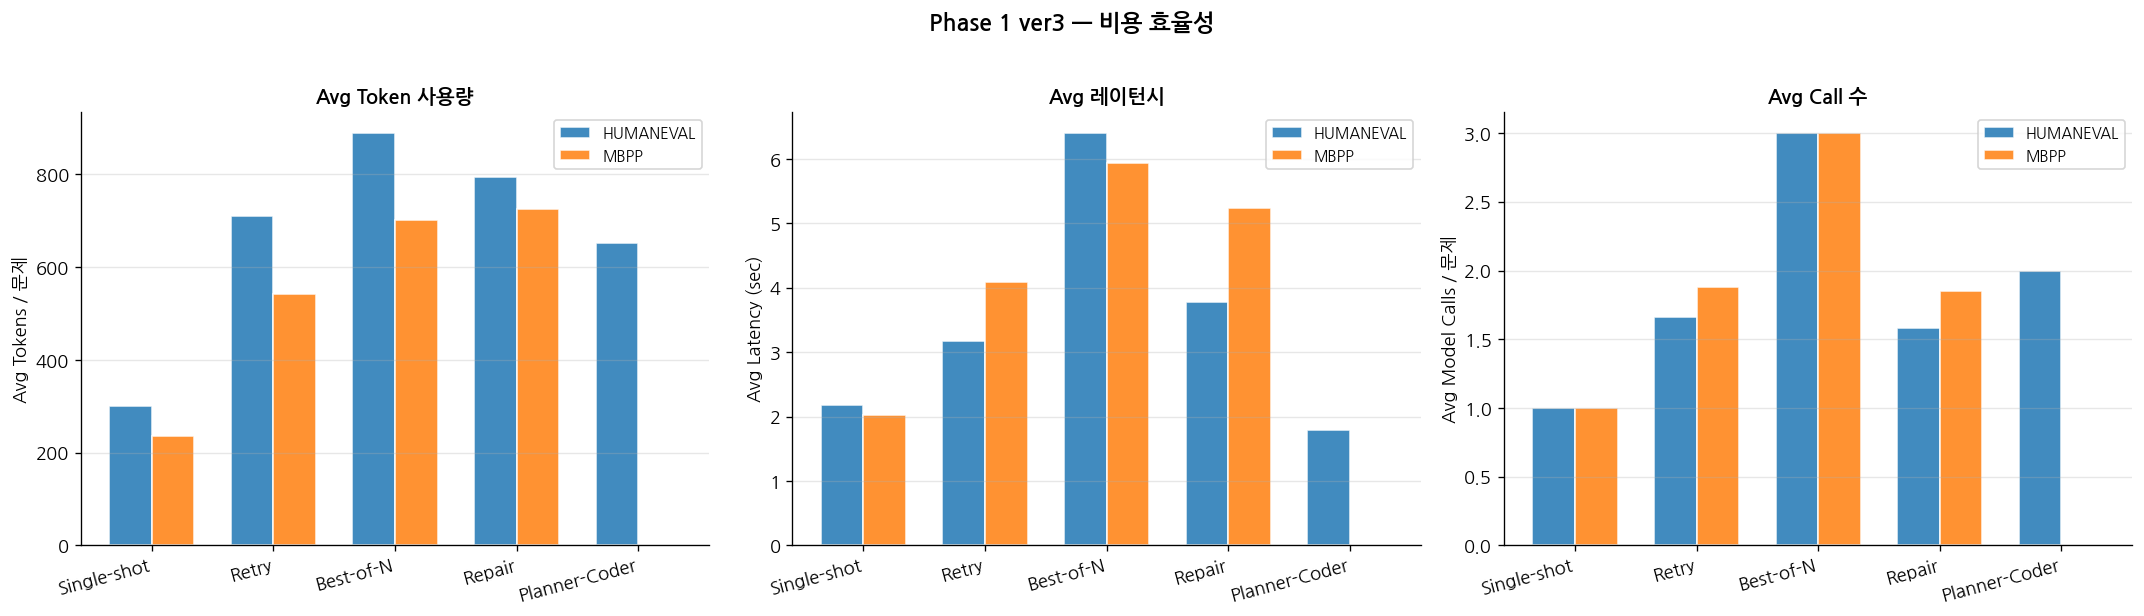


=== 효율성 지표 테이블 ===


,dataset,method_label,pass@1,avg_tokens,avg_latency,avg_calls,pass_per_1k_tokens
0,humaneval,Single-shot,0.7378,300.3293,2.1841,1.0000,2.4567
1,humaneval,Retry,0.6951,709.5915,3.1794,1.6646,0.9796
2,humaneval,Best-of-N,0.7744,889.0488,6.4004,3.0000,0.8710
3,humaneval,Repair,0.8537,794.2134,3.7762,1.5793,1.0748
4,humaneval,Planner-Coder,0.7927,652.1829,1.7963,2.0000,1.2154
5,mbpp,Single-shot,0.4759,236.7406,2.0194,1.0000,2.0104
6,mbpp,Retry,0.6551,542.4171,4.0876,1.8770,1.2077
7,mbpp,Best-of-N,0.6043,701.0294,5.9368,3.0000,0.8620
8,mbpp,Repair,0.6765,725.4198,5.2428,1.8529,0.9325


In [9]:
# pass@1 대비 평균 토큰 비용 (효율성)
eff_rows = []
for (dataset, method), s in summaries.items():
    if s is None:
        continue
    p1    = s.get('pass_at_1', s.get('pass@1', 0.0))
    tok   = s.get('avg_tokens', 0.0)
    lat   = s.get('avg_latency', 0.0)
    calls = s.get('avg_calls', 0.0)
    eff_rows.append({
        'dataset'      : dataset,
        'method'       : method,
        'method_label' : METHOD_LABELS.get(method, method),
        'pass@1'       : p1,
        'avg_tokens'   : tok,
        'avg_latency'  : lat,
        'avg_calls'    : calls,
        'pass_per_1k_tokens': (p1 / tok * 1000) if tok > 0 else 0,
    })

df_eff = pd.DataFrame(eff_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def grouped_bar(df_eff, ycol, ylabel, title, ax):
    methods_present = [m for m in METHODS if m in df_eff['method'].values]
    x = np.arange(len(methods_present))
    w = 0.35
    for di, dataset in enumerate(DATASETS):
        sub = df_eff[df_eff['dataset'] == dataset].set_index('method').reindex(methods_present)
        vals = sub[ycol].fillna(0).values
        ax.bar(x + di * w, vals, width=w, label=dataset.upper(), alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in methods_present], rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

grouped_bar(df_eff, 'avg_tokens',   'Avg Tokens / 문제',     'Avg Token 사용량',    axes[0])
grouped_bar(df_eff, 'avg_latency',  'Avg Latency (sec)',      'Avg 레이턴시',        axes[1])
grouped_bar(df_eff, 'avg_calls',    'Avg Model Calls / 문제', 'Avg Call 수',         axes[2])

plt.suptitle('Phase 1 ver3 — 비용 효율성', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_efficiency.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== 효율성 지표 테이블 ===')
display(df_eff[['dataset', 'method_label', 'pass@1', 'avg_tokens', 'avg_latency',
                'avg_calls', 'pass_per_1k_tokens']].round(4))

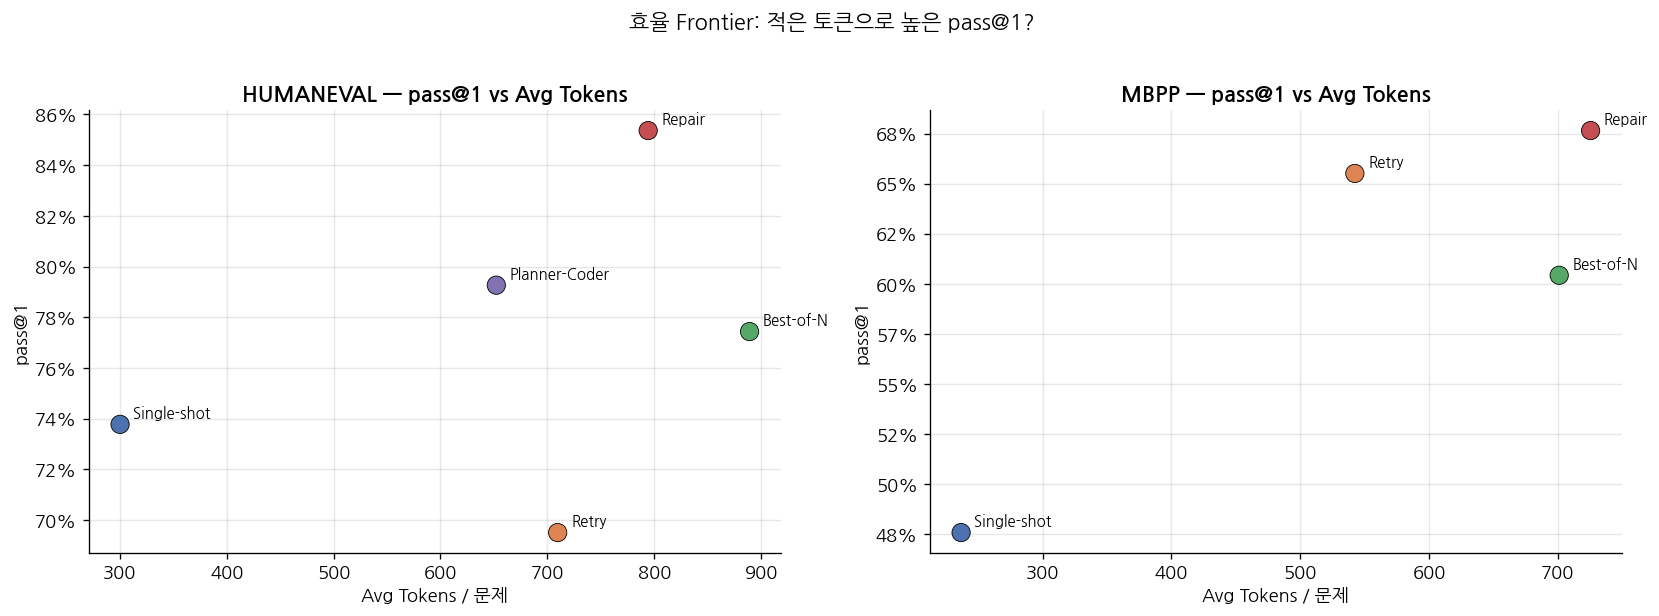

In [10]:
# pass@1 vs avg_tokens 산점도 (효율 frontier)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7 * len(DATASETS), 5))
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    sub = df_eff[df_eff['dataset'] == dataset]
    colors_list = [COLORS.get(m, '#999') for m in sub['method'].values]
    ax.scatter(sub['avg_tokens'], sub['pass@1'],
               c=colors_list, s=120, zorder=5, edgecolors='black', linewidths=0.5)
    for _, row in sub.iterrows():
        ax.annotate(row['method_label'],
                    xy=(row['avg_tokens'], row['pass@1']),
                    xytext=(8, 4), textcoords='offset points', fontsize=9)
    ax.set_title(f'{dataset.upper()} — pass@1 vs Avg Tokens', fontsize=13, fontweight='bold')
    ax.set_xlabel('Avg Tokens / 문제')
    ax.set_ylabel('pass@1')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.grid(alpha=0.3)

plt.suptitle('효율 Frontier: 적은 토큰으로 높은 pass@1?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_efficiency_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Step-level 상세 분석

In [11]:
# step_logs를 하나의 DataFrame으로 합치기
step_dfs = []
for (dataset, method), steps in step_logs_all.items():
    if not steps:
        continue
    df = pd.DataFrame(steps)
    df['dataset'] = dataset
    df['method']  = method
    step_dfs.append(df)

if step_dfs:
    df_steps = pd.concat(step_dfs, ignore_index=True)
    print(f'전체 step 수: {len(df_steps):,}')
    print(f'컬럼: {list(df_steps.columns)}')
else:
    df_steps = pd.DataFrame()
    print('⚠️  step_logs 데이터 없음')

전체 step 수: 4,407
컬럼: ['run_id', 'dataset', 'problem_id', 'method', 'trajectory_id', 'step_id', 'call_index', 'candidate_id', 'stage', 'is_retry', 'is_repair', 'is_planner', 'input_tokens', 'output_tokens', 'total_tokens', 'latency_sec', 'code', 'exec_ok', 'test_pass', 'status', 'error_type', 'error_stage', 'error_message', 'tests_passed', 'tests_total', 'code_length', 'selected', 'selection_rank', 'entry_point', 'planner_output']


/tmp/ipykernel_1345012/2364706881.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_steps = pd.concat(step_dfs, ignore_index=True)


In [12]:
if not df_steps.empty:
    # stage별 pass율 (generate / retry / repair / plan)
    if 'stage' in df_steps.columns and 'status' in df_steps.columns:
        df_steps['is_pass'] = df_steps['status'] == 'PASS'

        df_no_plan = df_steps[df_steps['stage'] != 'plan']  # plan step은 코드 미생성이므로 제외

        stage_pass = (
            df_no_plan
            .groupby(['dataset', 'method', 'stage'])['is_pass']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'pass_rate', 'count': 'n_steps'})
            .reset_index()
        )

        # 문제당 평균 stage 실행 횟수: problem_id별 실행 횟수를 내고 평균
        avg_per_prob = (
            df_no_plan
            .groupby(['dataset', 'method', 'stage', 'problem_id'])
            .size()                                      # 문제별 해당 stage 실행 횟수
            .reset_index(name='steps_for_this_problem')
            .groupby(['dataset', 'method', 'stage'])['steps_for_this_problem']
            .mean()                                      # 문제당 평균
            .reset_index(name='avg_steps_per_problem')
        )

        stage_pass = stage_pass.merge(avg_per_prob, on=['dataset', 'method', 'stage'], how='left')

        print('\n=== Stage별 Pass Rate (plan 제외) ===')
        print('  n_steps               : 해당 stage가 전체 실험에서 실행된 총 횟수')
        print('  avg_steps_per_problem : 해당 stage가 발생한 문제당 평균 실행 횟수')
        display(stage_pass.round(4))


=== Stage별 Pass Rate (plan 제외) ===
  n_steps               : 해당 stage가 전체 실험에서 실행된 총 횟수
  avg_steps_per_problem : 해당 stage가 발생한 문제당 평균 실행 횟수


,dataset,method,stage,pass_rate,n_steps,avg_steps_per_problem
0,humaneval,bestofn,generate,0.6687,492,3.0000
1,humaneval,planner_coder,generate,0.7927,164,1.0000
2,humaneval,repair,generate,0.6829,164,1.0000
3,humaneval,repair,repair,0.2947,95,1.8269
4,humaneval,retry,generate,0.6646,164,1.0000
5,humaneval,retry,retry,0.0459,109,1.9818
6,humaneval,single,generate,0.7378,164,1.0000
7,mbpp,bestofn,generate,0.4688,1122,3.0000
8,mbpp,repair,generate,0.4947,374,1.0000
9,mbpp,repair,repair,0.2132,319,1.6878


/tmp/ipykernel_1345012/1859780059.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_1345012/1859780059.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True,


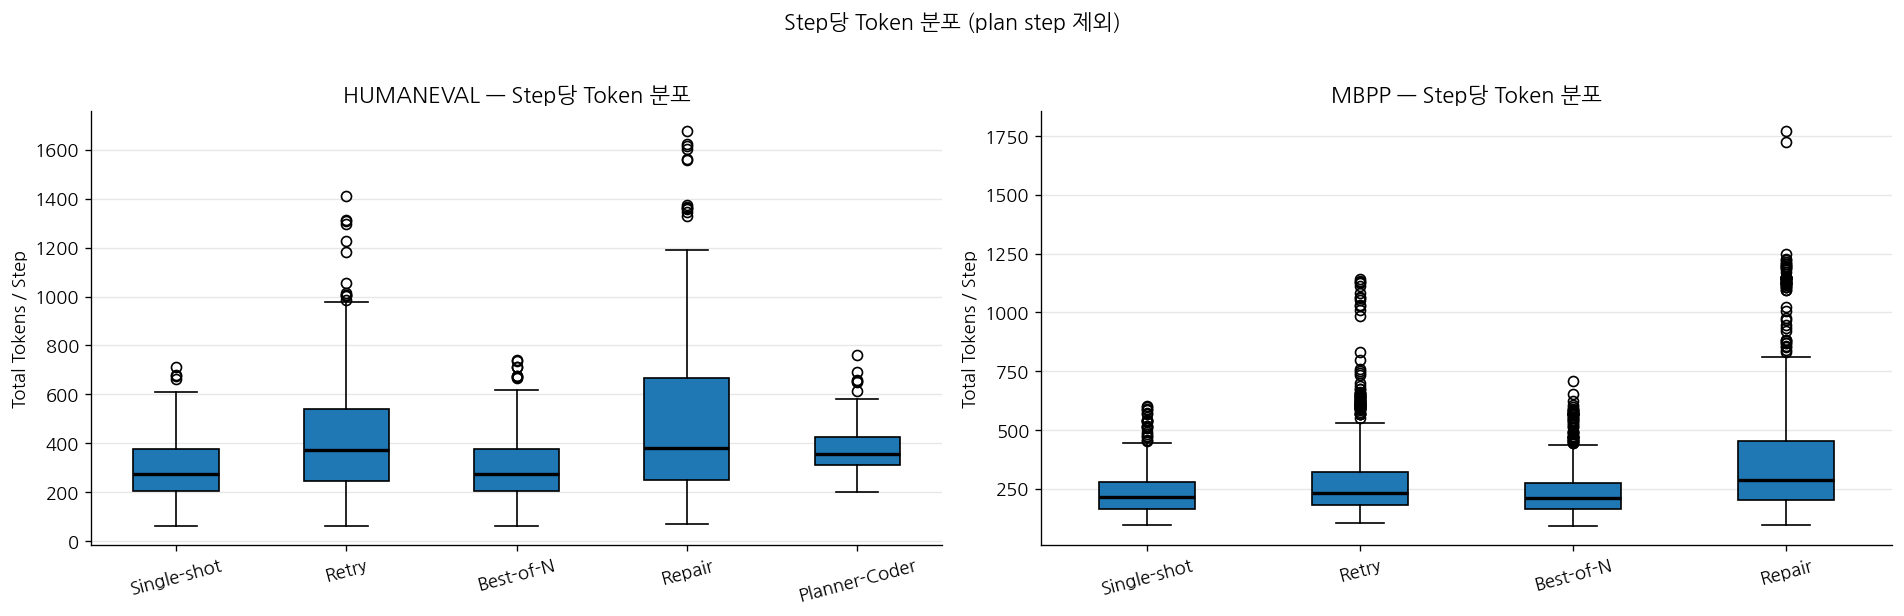

In [13]:
# step당 토큰 분포 (boxplot)
if not df_steps.empty and 'total_tokens' in df_steps.columns:
    methods_present = [m for m in METHODS if m in df_steps['method'].values]

    fig, axes = plt.subplots(1, len(DATASETS), figsize=(8 * len(DATASETS), 5))
    if len(DATASETS) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, DATASETS):
        sub = df_steps[(df_steps['dataset'] == dataset) & (df_steps['stage'] != 'plan')]
        data = [sub[sub['method'] == m]['total_tokens'].dropna().values
                for m in methods_present if m in sub['method'].values]
        labels = [METHOD_LABELS.get(m, m) for m in methods_present if m in sub['method'].values]

        ax.boxplot(data, labels=labels, patch_artist=True,
                   medianprops=dict(color='black', linewidth=2))
        ax.set_title(f'{dataset.upper()} — Step당 Token 분포')
        ax.set_ylabel('Total Tokens / Step')
        ax.tick_params(axis='x', rotation=15)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Step당 Token 분포 (plan step 제외)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_token_dist.png', bbox_inches='tight', dpi=150)
    plt.show()

---
## 8. MBPP Failure Breakdown

=== MBPP Failure Breakdown ===


,code_failed,setup_failed,test_failed,semantic_failed,execution_failed
method,,,,,
Single-shot,127,1,68,62,6
Retry,124,0,5,5,0
Best-of-N,83,0,65,58,7
Repair,114,0,7,7,0


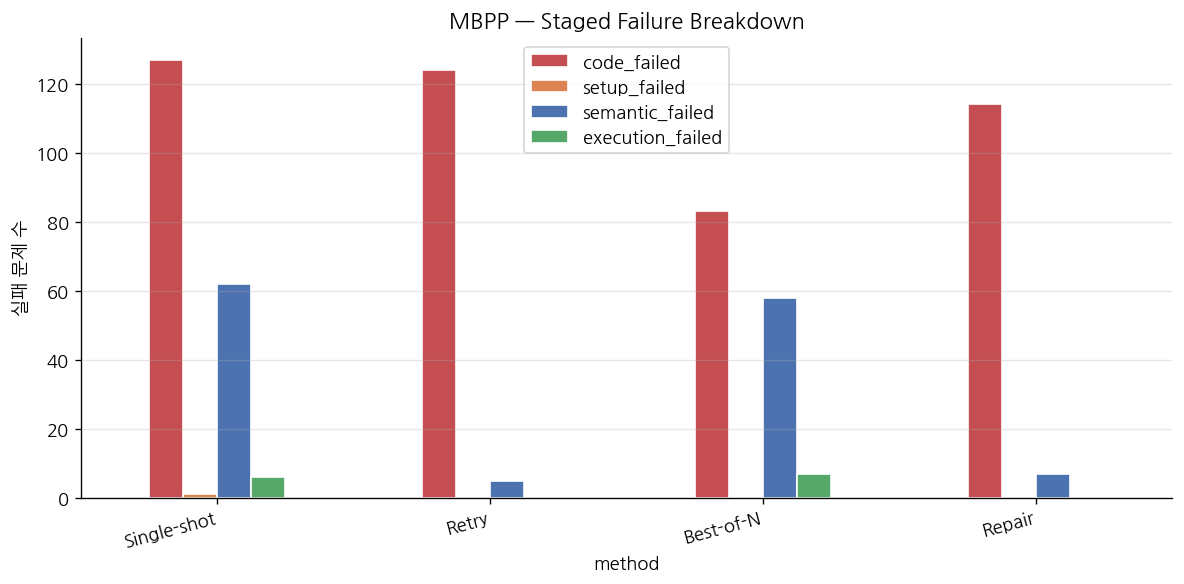

In [14]:
# summary.json의 extra_summary (MBPP 전용)
mbpp_breakdown_rows = []
for (dataset, method), s in summaries.items():
    if dataset != 'mbpp' or s is None:
        continue
    extra = s.get('extra_summary', {})
    if not extra:
        continue
    mbpp_breakdown_rows.append({
        'method'         : METHOD_LABELS.get(method, method),
        'code_failed'    : extra.get('code_failed', 0),
        'setup_failed'   : extra.get('setup_failed', 0),
        'test_failed'    : extra.get('test_failed', 0),
        'semantic_failed': extra.get('semantic_failed', 0),
        'execution_failed': extra.get('execution_failed', 0),
    })

if mbpp_breakdown_rows:
    df_mbpp = pd.DataFrame(mbpp_breakdown_rows).set_index('method')
    # method 순서 고정
    order = [METHOD_LABELS.get(m, m) for m in METHODS if METHOD_LABELS.get(m, m) in df_mbpp.index]
    df_mbpp = df_mbpp.reindex(order)

    print('=== MBPP Failure Breakdown ===')
    display(df_mbpp.style.background_gradient(cmap='Reds', axis=0))

    # 시각화
    df_mbpp[['code_failed', 'setup_failed', 'semantic_failed', 'execution_failed']].plot(
        kind='bar', figsize=(10, 5), edgecolor='white',
        color=['#C44E52', '#DD8452', '#4C72B0', '#55A868'],
        title='MBPP — Staged Failure Breakdown',
    )
    plt.xticks(rotation=15, ha='right')
    plt.ylabel('실패 문제 수')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_mbpp_failure_breakdown.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('⚠️  MBPP extra_summary 데이터가 없습니다.')

---
## 9. 종합 결론 요약

In [15]:
print('=' * 60)
print('📊 Phase 1 ver3 — 결론 요약')
print('=' * 60)

for dataset in DATASETS:
    if dataset not in df_summary.index.get_level_values('dataset'):
        continue
    sub = df_summary.loc[dataset].reindex([m for m in METHODS if m in df_summary.loc[dataset].index])

    best_pass  = sub['pass@1'].idxmax()
    best_exec  = sub['exec_success_rate'].idxmax()
    best_cond  = sub['conditional_pass'].idxmax()
    low_token  = sub['avg_tokens'].idxmin()

    print(f'\n[{dataset.upper()}]')
    print(f'  최고 pass@1          : {METHOD_LABELS.get(best_pass, best_pass):20s} ({sub.loc[best_pass, "pass@1"]:.4f})')
    print(f'  최고 exec_success    : {METHOD_LABELS.get(best_exec, best_exec):20s} ({sub.loc[best_exec, "exec_success_rate"]:.4f})')
    print(f'  최고 conditional_pass: {METHOD_LABELS.get(best_cond, best_cond):20s} ({sub.loc[best_cond, "conditional_pass"]:.4f})')
    print(f'  최소 avg_tokens      : {METHOD_LABELS.get(low_token, low_token):20s} ({sub.loc[low_token, "avg_tokens"]:.1f})')

    # single 대비 gain
    if 'single' in sub.index:
        single_p1 = sub.loc['single', 'pass@1']
        print(f'\n  Single-shot 대비 pass@1 gain:')
        for m in sub.index:
            if m == 'single':
                continue
            gain = sub.loc[m, 'pass@1'] - single_p1
            sign = '+' if gain >= 0 else ''
            print(f'    {METHOD_LABELS.get(m, m):20s}: {sign}{gain:.4f}')

print('\n' + '=' * 60)

📊 Phase 1 ver3 — 결론 요약

[HUMANEVAL]
  최고 pass@1          : Repair               (0.8537)
  최고 exec_success    : Repair               (0.9329)
  최고 conditional_pass: Retry                (0.9421)
  최소 avg_tokens      : Single-shot          (300.3)

  Single-shot 대비 pass@1 gain:
    Retry               : -0.0427
    Best-of-N           : +0.0366
    Repair              : +0.1159
    Planner-Coder       : +0.0549

[MBPP]
  최고 pass@1          : Repair               (0.6765)
  최고 exec_success    : Best-of-N            (0.7781)
  최고 conditional_pass: Retry                (0.9800)
  최소 avg_tokens      : Single-shot          (236.7)

  Single-shot 대비 pass@1 gain:
    Retry               : +0.1791
    Best-of-N           : +0.1283
    Repair              : +0.2005

